# 02 - Expert Demonstration Collection (M2)

**Group members:** Marco De Palma, Em Echeverria, Leah Sarouphin, Juan Jose Rincon Briceño, Matteo Mainetti

Roll out the deterministic expert and record (observation, action) pairs. This notebook **re-collects a demonstration set live** from the submitted expert (seeded) and runs the EDA. The canonical 100-episode dataset used for the full results is produced by `collect_demos.py`.

In [1]:
import sys, os, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display
from src import seeding, config
seeding.set_seed(0)            # numpy + torch + python random
DEVICE = config.device()
OUT, MODELS, DATA = ROOT/'outputs', ROOT/'models', ROOT/'data'/'demonstrations'
def show(name):
    p = OUT/name
    display(Image(str(p))) if p.exists() else print('precomputed figure not found:', name,
        '- run the corresponding script (see README)')
def results(name):
    p = OUT/name
    return json.load(open(p)) if p.exists() else {}
print('setup ok | seeds set | device', DEVICE)

setup ok | seeds set | device mps


## Collect demonstrations live and check the quality gate

Deterministic actions (Gaussian-policy mean). 40 episodes here for speed; `collect_demos.py` collects 100. Saved to a `_nb` folder so the canonical dataset is untouched.

,env,episodes,transitions,mean_return,mean_len,gate_pct
0,Walker2d-v4,40,39224,6092.5,980.6,97.5
1,Ant-v4,40,37359,5866.8,934.0,85.0


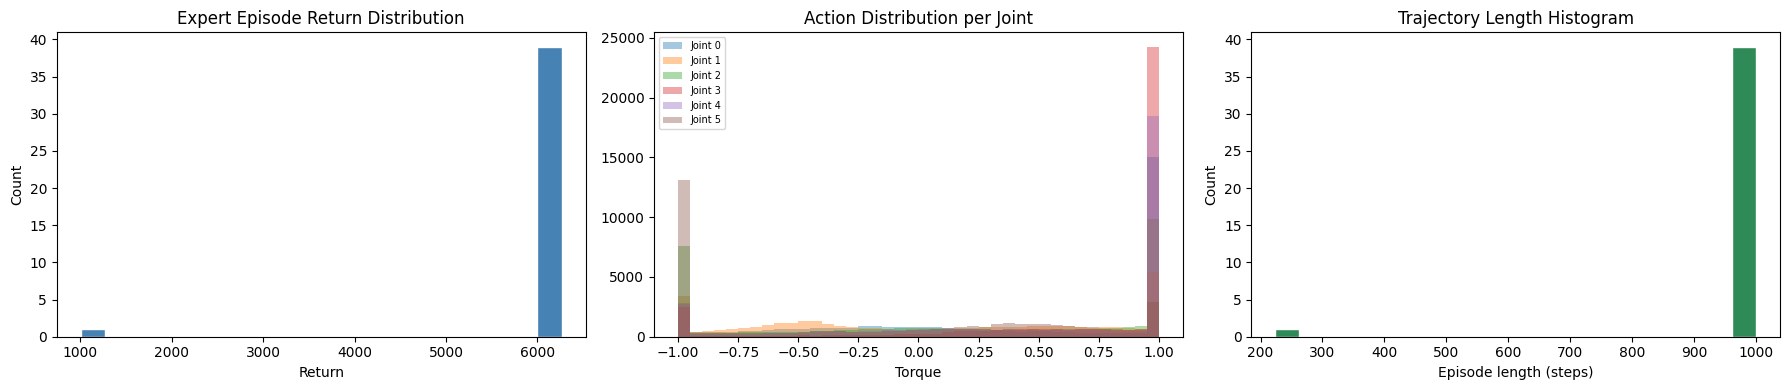

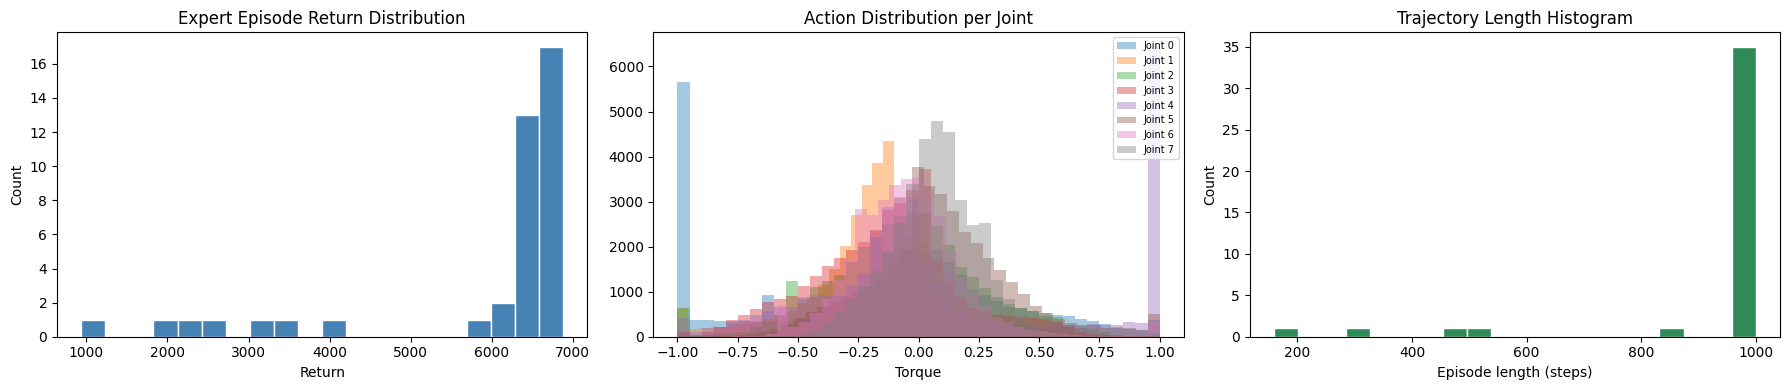

In [2]:
from stable_baselines3 import PPO
from src import collect, eval as ev, plotting
rows = []
for env in ['Walker2d-v4', 'Ant-v4']:
    mdir = MODELS/f'ppo_expert_{env}'
    if not (mdir/'best_model.zip').exists():
        print('expert missing for', env); continue
    model = PPO.load(mdir/'best_model', device='cpu')
    vn = mdir/'vecnormalize.pkl'
    norm = ev.load_obs_normalizer(vn)
    d = collect.collect(model, env, n_episodes=40, out_dir=DATA/f'{env}_nb',
                        seed=0, obs_transform=norm)
    r = d['episode_returns']; thr = (2/3)*r.mean()
    rows.append(dict(env=env, episodes=len(r), transitions=len(d['observations']),
        mean_return=round(float(r.mean()),1), mean_len=round(float(d['episode_lengths'].mean()),1),
        gate_pct=round(100*float((r>thr).mean()),1)))
    plotting.save(plotting.dataset_eda(r, d['actions'], d['episode_lengths']),
                  OUT/f'dataset_analysis_{env}_nb.png')
pd.DataFrame(rows)

## EDA: returns, per-joint actions, trajectory lengths (live)

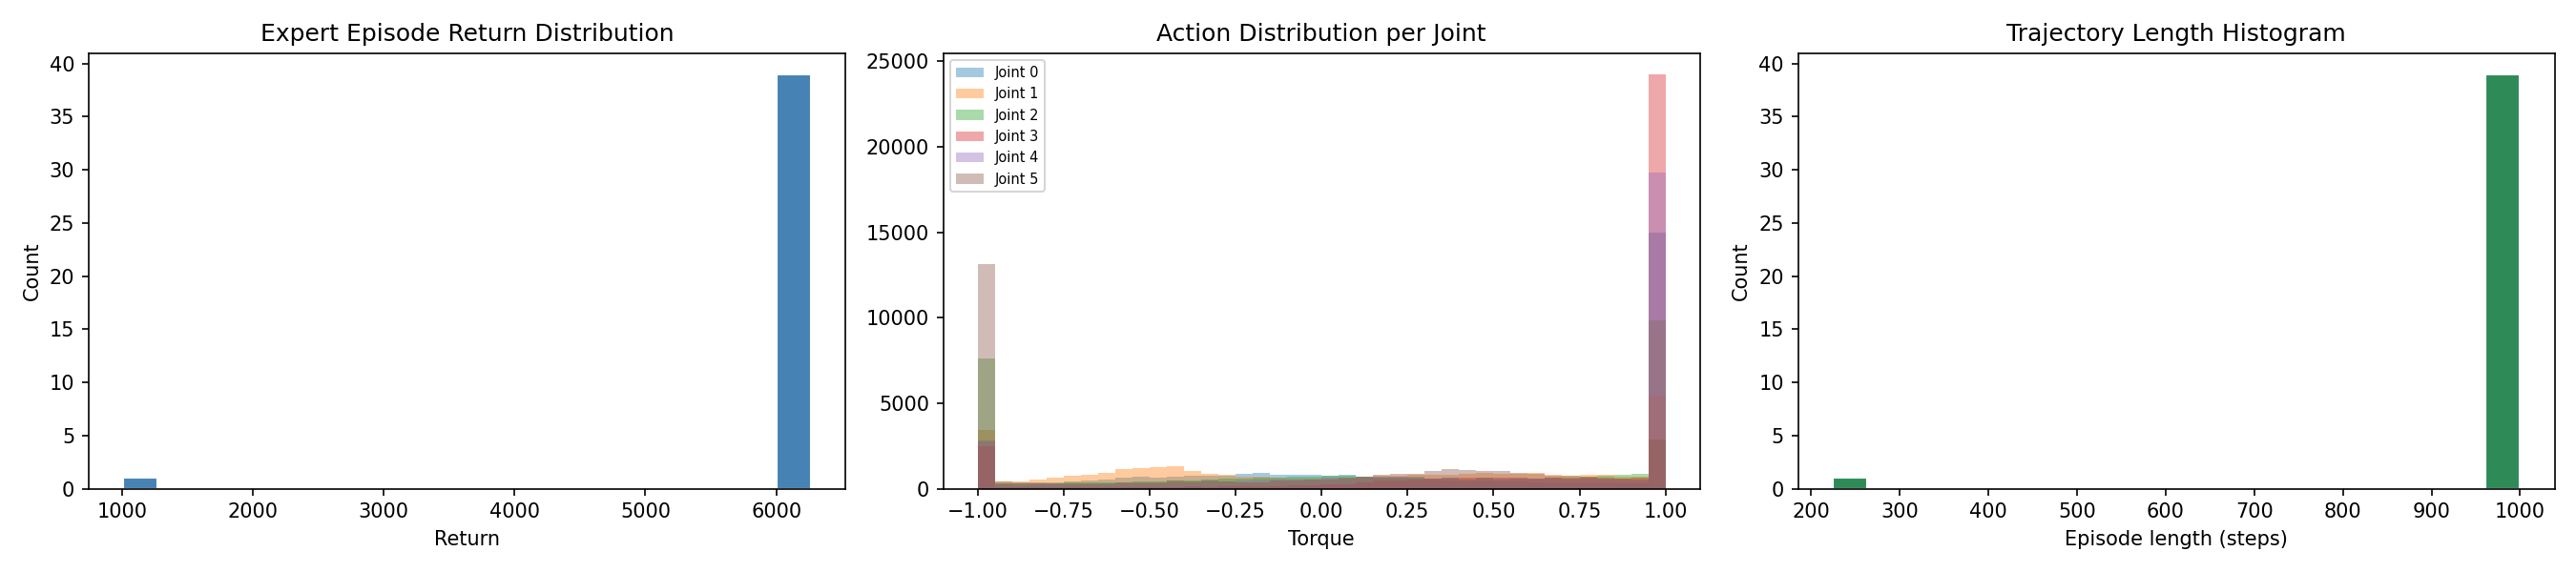

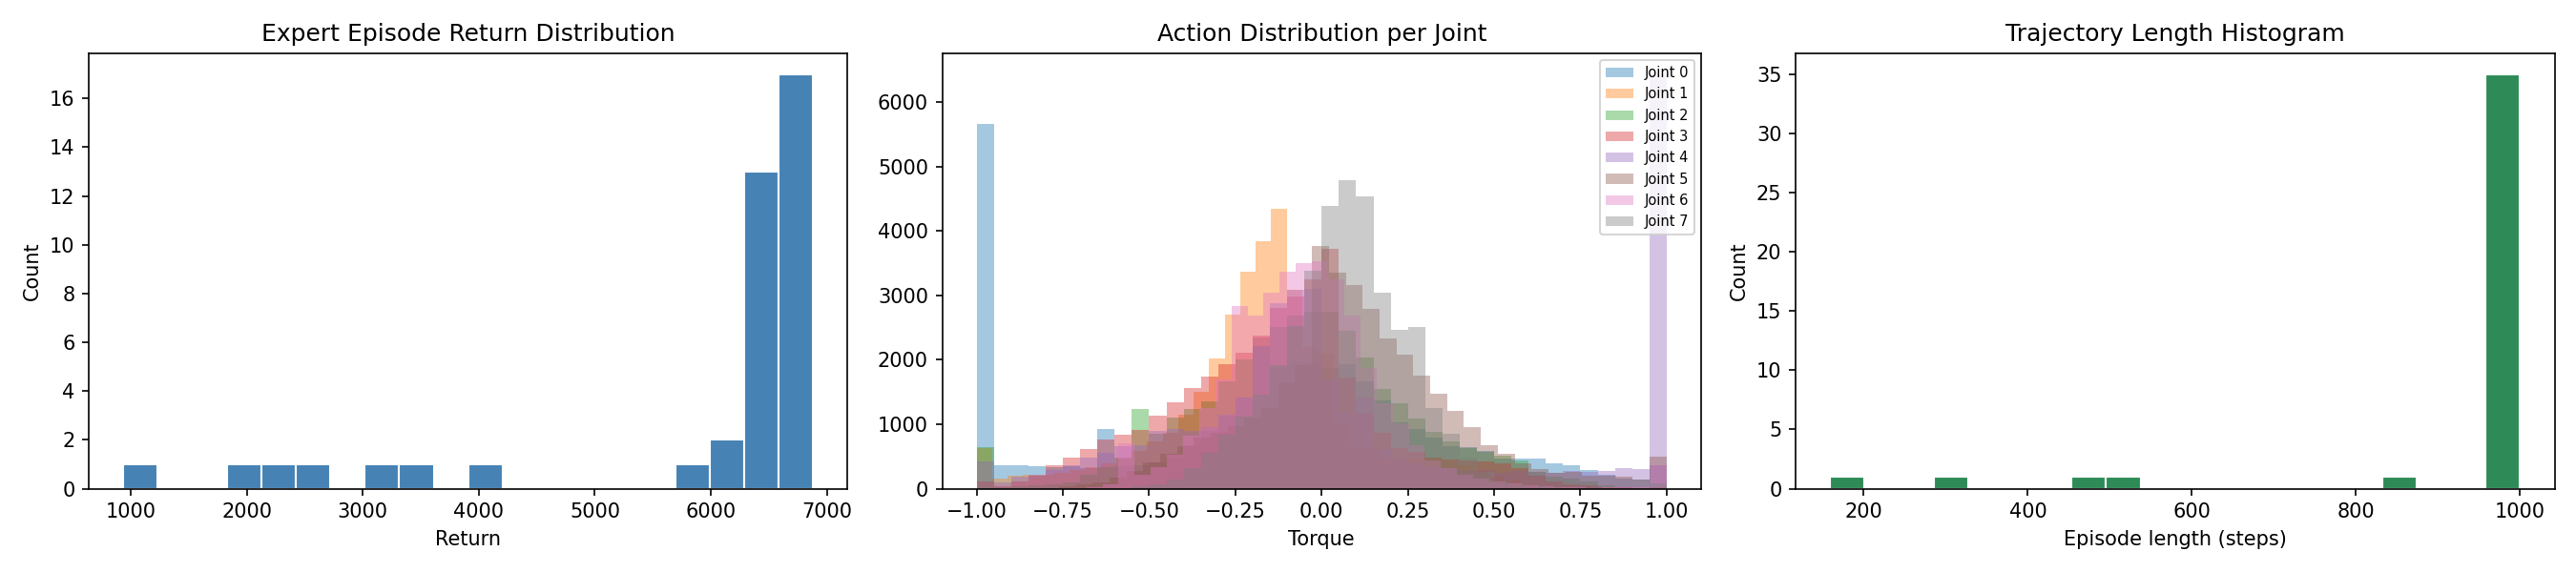

In [3]:
show('dataset_analysis_Walker2d-v4_nb.png')
show('dataset_analysis_Ant-v4_nb.png')

>= 50 complete episodes (we collect 100 canonically), NumPy arrays, deterministic actions, gate passed (>= 90% above two-thirds of the mean). Returns are tight and high; trajectory lengths sit near the 1000-step cap (experts rarely fall); per-joint actions show near-saturated control (Walker2d especially), which makes the strong experts harder to clone.